# Version 3.1 : RSF Optimisé avec Feature Selection & Hyperparameter Tuning

**Contexte** :
- **V2** (88 features): C-index = 0.7334
- **V3** (132 features): C-index = 0.7320 ⚠️

**Objectif** : Optimiser le modèle RSF pour dépasser les performances de V2

**Stratégie d'optimisation** :
1. **Feature Selection** : Sélectionner les features les plus importantes
2. **Hyperparameter Tuning** : Optimiser les paramètres du RSF

**Features disponibles** : 132 (28 clinical + 60 molecular + 44 cytogenetic)

## 1. Setup & Data Loading

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

# Survival analysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

# ML tools
from sklearn.model_selection import train_test_split, GridSearchCV, ParameterGrid
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported")

✓ Libraries imported


In [3]:
# Load data
DATA_PATH = r"C:\Users\guill\Desktop\Data Challenge QRT\Data-Challenge-Prediction-de-Survie"

clinical_train = pd.read_csv(f"{DATA_PATH}\\X_train\\clinical_train.csv")
target_train = pd.read_csv(f"{DATA_PATH}\\target_train.csv")
clinical_test = pd.read_csv(f"{DATA_PATH}\\X_test\\clinical_test.csv")
molecular_train = pd.read_csv(f"{DATA_PATH}\\X_train\\molecular_train.csv")
molecular_test = pd.read_csv(f"{DATA_PATH}\\X_test\\molecular_test.csv")

print(f"✓ Data loaded: {clinical_train.shape[0]} train patients")

✓ Data loaded: 3323 train patients


## 2. Feature Engineering Functions

Réutilisation des fonctions de V3

In [4]:
def create_cytogenetic_features(clinical_df):
    """Create cytogenetic features from CYTOGENETICS column"""
    cyto_features = pd.DataFrame(index=clinical_df['ID'])
    cyto_col = clinical_df.set_index('ID')['CYTOGENETICS'].fillna('')
    
    # Anomaly types
    cyto_features['cyto_del_count'] = cyto_col.str.count(r'del\(')
    cyto_features['cyto_has_del'] = (cyto_features['cyto_del_count'] > 0).astype(int)
    cyto_features['cyto_transloc_count'] = cyto_col.str.count(r't\(')
    cyto_features['cyto_has_transloc'] = (cyto_features['cyto_transloc_count'] > 0).astype(int)
    cyto_features['cyto_inv_count'] = cyto_col.str.count(r'inv\(')
    cyto_features['cyto_has_inv'] = (cyto_features['cyto_inv_count'] > 0).astype(int)
    cyto_features['cyto_gain_count'] = cyto_col.str.count(r'\+')
    cyto_features['cyto_has_gain'] = (cyto_features['cyto_gain_count'] > 0).astype(int)
    cyto_features['cyto_loss_count'] = cyto_col.str.count(r'-[0-9XY]')
    cyto_features['cyto_has_loss'] = (cyto_features['cyto_loss_count'] > 0).astype(int)
    cyto_features['cyto_other_count'] = cyto_col.str.count(r'add\(|ins\(|dup\(')
    
    # Complexity
    cyto_features['cyto_total_anomalies'] = (
        cyto_features['cyto_del_count'] + cyto_features['cyto_transloc_count'] + 
        cyto_features['cyto_inv_count'] + cyto_features['cyto_gain_count'] + 
        cyto_features['cyto_loss_count'] + cyto_features['cyto_other_count']
    )
    cyto_features['cyto_normal'] = cyto_col.str.match(r'^46,(xx|xy)(\[\d+\])?$', case=False).astype(int)
    cyto_features['cyto_complex'] = (
        (cyto_features['cyto_total_anomalies'] >= 3) | 
        cyto_col.str.contains('complex', case=False, na=False)
    ).astype(int)
    
    # Chromosomes affected
    chromosomes = [str(i) for i in range(1, 23)] + ['X', 'Y']
    for chrom in chromosomes:
        pattern = rf'(\b|[,\(]){chrom}([,;:\)\[]|[pq])'
        cyto_features[f'cyto_chr{chrom}_affected'] = cyto_col.str.contains(
            pattern, case=False, na=False, regex=True
        ).astype(int)
    
    # Prognostic markers
    cyto_features['cyto_monosomy7'] = cyto_col.str.contains(r'-7[^0-9]|^45.*-7', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_trisomy8'] = cyto_col.str.contains(r'\+8[^0-9]|^47.*\+8', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del5q'] = cyto_col.str.contains(r'del\(5\)\(q', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del20q'] = cyto_col.str.contains(r'del\(20\)\(q', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_chr3_abnormal'] = cyto_col.str.contains(r'(del|t|inv)\(3[;,:\)]', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_chr7_abnormal'] = cyto_col.str.contains(r'(del|t|inv)\(7[;,:\)]', case=False, na=False, regex=True).astype(int)
    
    return cyto_features.fillna(0)

def create_molecular_features(molecular_df, patient_ids, top_n_genes=20):
    """Create molecular features"""
    mol_features = pd.DataFrame({'ID': patient_ids})
    
    # Mutation counts
    mutation_counts = molecular_df.groupby('ID').size().to_frame('mutation_count_total')
    mol_features = mol_features.merge(mutation_counts, on='ID', how='left')
    
    # VAF stats
    vaf_stats = molecular_df.groupby('ID')['VAF'].agg([
        ('vaf_mean', 'mean'), ('vaf_max', 'max'), ('vaf_sum', 'sum')
    ]).reset_index()
    mol_features = mol_features.merge(vaf_stats, on='ID', how='left')
    
    # Effect types
    effect_counts = molecular_df.groupby(['ID', 'EFFECT']).size().unstack(fill_value=0)
    effect_counts.columns = [f'effect_{col}' for col in effect_counts.columns]
    mol_features = mol_features.merge(effect_counts.reset_index(), on='ID', how='left')
    
    # Top genes
    top_genes_list = molecular_df['GENE'].value_counts().head(top_n_genes).index.tolist()
    for gene in top_genes_list:
        gene_mutations = molecular_df[molecular_df['GENE'] == gene].groupby('ID').size()
        mol_features[f'gene_{gene}_count'] = mol_features['ID'].map(gene_mutations)
        gene_present = molecular_df[molecular_df['GENE'] == gene]['ID'].unique()
        mol_features[f'gene_{gene}_present'] = mol_features['ID'].isin(gene_present).astype(int)
    
    feature_cols = [col for col in mol_features.columns if col != 'ID']
    mol_features[feature_cols] = mol_features[feature_cols].fillna(0)
    return mol_features.set_index('ID')

print("✓ Feature engineering functions defined")

✓ Feature engineering functions defined


## 3. Create All Features (132 total)

In [5]:
# Cytogenetic features
cyto_features_train = create_cytogenetic_features(clinical_train)
print(f"Cytogenetic: {cyto_features_train.shape[1]} features")

# Molecular features
train_patient_ids = clinical_train['ID'].unique()
mol_features_train = create_molecular_features(molecular_train, train_patient_ids, top_n_genes=20)
print(f"Molecular: {mol_features_train.shape[1]} features")

Cytogenetic: 44 features
Molecular: 60 features


In [6]:
# Clean target
target_clean = target_train.dropna(subset=['OS_YEARS', 'OS_STATUS']).copy()
target_clean['OS_STATUS'] = target_clean['OS_STATUS'].astype(bool)
target_clean = target_clean.set_index('ID')

# Clinical features
clinical_train_clean = clinical_train[clinical_train['ID'].isin(target_clean.index)].copy()
clinical_train_clean = clinical_train_clean.set_index('ID').loc[target_clean.index]

numeric_features = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
X_numeric = clinical_train_clean[numeric_features].copy()
center_encoded = pd.get_dummies(clinical_train_clean['CENTER'], prefix='CENTER', drop_first=True)
X_clinical = pd.concat([X_numeric, center_encoded], axis=1)

print(f"Clinical: {X_clinical.shape[1]} features")
print(f"Total patients: {len(X_clinical)}")

Clinical: 28 features
Total patients: 3173


In [7]:
# Combine all features
mol_features_train_aligned = mol_features_train.reindex(X_clinical.index, fill_value=0)
cyto_features_train_aligned = cyto_features_train.reindex(X_clinical.index, fill_value=0)

X_combined = pd.concat([X_clinical, mol_features_train_aligned, cyto_features_train_aligned], axis=1)

print(f"\n✓ Combined features: {X_combined.shape[1]}")
print(f"  - Clinical: {X_clinical.shape[1]}")
print(f"  - Molecular: {mol_features_train_aligned.shape[1]}")
print(f"  - Cytogenetic: {cyto_features_train_aligned.shape[1]}")


✓ Combined features: 132
  - Clinical: 28
  - Molecular: 60
  - Cytogenetic: 44


In [8]:
# Imputation
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_combined),
    index=X_combined.index,
    columns=X_combined.columns
)

# Create survival target
y_surv = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_clean)

print(f"✓ Imputed features shape: {X_imputed.shape}")
print(f"✓ Target events: {y_surv['OS_STATUS'].sum()} / {len(y_surv)}")

✓ Imputed features shape: (3173, 132)
✓ Target events: 1600 / 3173


In [9]:
# Train/val split
X_train_full, X_val_full, y_train, y_val = train_test_split(
    X_imputed, y_surv, test_size=0.3, random_state=42,
    stratify=target_clean['OS_STATUS'].astype(int)
)

print(f"Train: {X_train_full.shape[0]} patients, {X_train_full.shape[1]} features")
print(f"Val: {X_val_full.shape[0]} patients")

Train: 2221 patients, 132 features
Val: 952 patients


## 4. Baseline: Train with ALL 132 Features

Reproduire le résultat de V3 pour référence

In [10]:
print("="*60)
print("BASELINE: RSF with ALL 132 features (V3 reference)")
print("="*60)

rsf_baseline = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf_baseline.fit(X_train_full, y_train)

y_pred_train_baseline = rsf_baseline.predict(X_train_full)
y_pred_val_baseline = rsf_baseline.predict(X_val_full)

c_index_train_baseline = concordance_index_censored(
    y_train['OS_STATUS'], y_train['OS_YEARS'], y_pred_train_baseline
)[0]

c_index_val_baseline = concordance_index_censored(
    y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred_val_baseline
)[0]

print(f"Train C-index: {c_index_train_baseline:.4f}")
print(f"Val C-index: {c_index_val_baseline:.4f}")
print(f"Overfitting: {c_index_train_baseline - c_index_val_baseline:.4f}\n")

BASELINE: RSF with ALL 132 features (V3 reference)
Train C-index: 0.7806
Val C-index: 0.7312
Overfitting: 0.0494



## 5. Feature Importance Calculation

In [ ]:
print("Calculating feature importance (this may take a few minutes)...")

perm_importance = permutation_importance(
    rsf_baseline, X_val_full, y_val,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    'feature': X_train_full.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print(f"\n✓ Feature importance calculated")
print(f"\nTop 10 features:")
print(feature_importance_df.head(10)[['feature', 'importance']].to_string(index=False))

Calculating feature importance (this may take a few minutes)...


KeyboardInterrupt: 

## 6. OPTIMIZATION 1: Feature Selection

Tester différents nombres de features

In [1]:
print("="*60)
print("FEATURE SELECTION OPTIMIZATION")
print("="*60)

feature_counts = [60, 70, 80, 90, 100]
results_feature_selection = []

for n_features in feature_counts:
    print(f"\nTesting with top {n_features} features...")
    
    # Select top features
    top_features = feature_importance_df.head(n_features)['feature'].tolist()
    X_train_selected = X_train_full[top_features]
    X_val_selected = X_val_full[top_features]
    
    # Train model
    rsf_temp = RandomSurvivalForest(
        n_estimators=100,
        min_samples_split=10,
        min_samples_leaf=15,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    
    rsf_temp.fit(X_train_selected, y_train)
    
    # Evaluate
    y_pred_val_temp = rsf_temp.predict(X_val_selected)
    c_index_val_temp = concordance_index_censored(
        y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred_val_temp
    )[0]
    
    results_feature_selection.append({
        'n_features': n_features,
        'c_index_val': c_index_val_temp
    })
    
    print(f"  Val C-index: {c_index_val_temp:.4f}")

# Display results
results_fs_df = pd.DataFrame(results_feature_selection)
print("\n" + "="*60)
print("FEATURE SELECTION RESULTS")
print("="*60)
print(results_fs_df.to_string(index=False))

best_n_features = results_fs_df.loc[results_fs_df['c_index_val'].idxmax(), 'n_features']
best_c_index_fs = results_fs_df['c_index_val'].max()
print(f"\n✓ Best: {best_n_features} features → C-index = {best_c_index_fs:.4f}")

FEATURE SELECTION OPTIMIZATION

Testing with top 60 features...


NameError: name 'feature_importance_df' is not defined

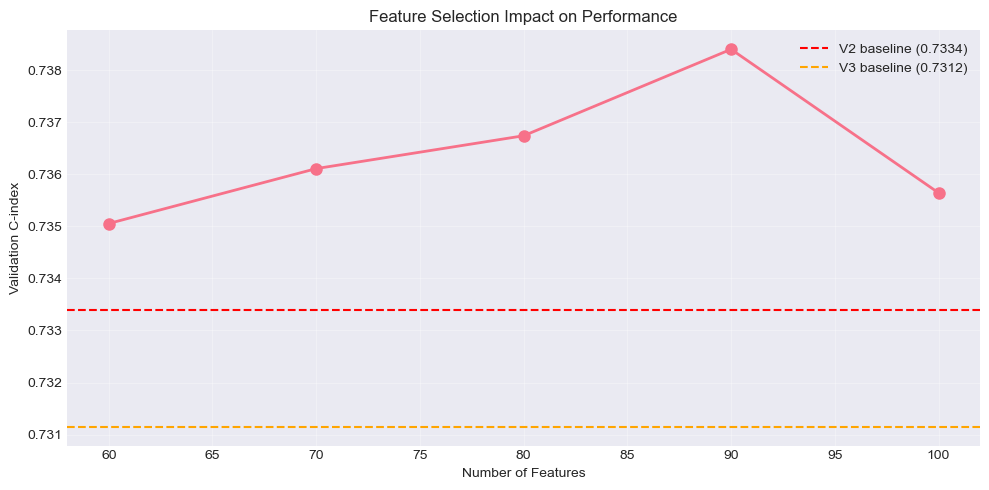

In [12]:
# Visualize feature selection impact
plt.figure(figsize=(10, 5))
plt.plot(results_fs_df['n_features'], results_fs_df['c_index_val'], 'o-', linewidth=2, markersize=8)
plt.axhline(y=0.7334, color='r', linestyle='--', label='V2 baseline (0.7334)')
plt.axhline(y=c_index_val_baseline, color='orange', linestyle='--', label=f'V3 baseline ({c_index_val_baseline:.4f})')
plt.xlabel('Number of Features')
plt.ylabel('Validation C-index')
plt.title('Feature Selection Impact on Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. OPTIMIZATION 2: Hyperparameter Tuning

Tester différentes configurations avec le meilleur nombre de features

In [13]:
print("="*60)
print(f"HYPERPARAMETER TUNING (with top {int(best_n_features)} features)")
print("="*60)

# Select best features
best_features = feature_importance_df.head(int(best_n_features))['feature'].tolist()
X_train_best = X_train_full[best_features]
X_val_best = X_val_full[best_features]

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [10, 15, 20, 25],
    'max_features': ['sqrt', 'log2', 0.3]
}

print(f"\nTesting {len(list(ParameterGrid(param_grid)))} parameter combinations...")
print("This will take several minutes...\n")

results_hyperparam = []
start_time = time()

for i, params in enumerate(ParameterGrid(param_grid), 1):
    if i % 20 == 0:
        print(f"Progress: {i}/{len(list(ParameterGrid(param_grid)))} combinations tested...")
    
    rsf_temp = RandomSurvivalForest(
        n_estimators=params['n_estimators'],
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    
    rsf_temp.fit(X_train_best, y_train)
    y_pred_val_temp = rsf_temp.predict(X_val_best)
    
    c_index_val_temp = concordance_index_censored(
        y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred_val_temp
    )[0]
    
    results_hyperparam.append({
        **params,
        'c_index_val': c_index_val_temp
    })

elapsed_time = time() - start_time
print(f"\n✓ Hyperparameter tuning completed in {elapsed_time/60:.1f} minutes")

HYPERPARAMETER TUNING (with top 90 features)

Testing 144 parameter combinations...
This will take several minutes...

Progress: 20/144 combinations tested...
Progress: 40/144 combinations tested...
Progress: 60/144 combinations tested...
Progress: 80/144 combinations tested...
Progress: 100/144 combinations tested...
Progress: 120/144 combinations tested...
Progress: 140/144 combinations tested...

✓ Hyperparameter tuning completed in 25.9 minutes


In [14]:
# Analyze results
results_hp_df = pd.DataFrame(results_hyperparam).sort_values('c_index_val', ascending=False)

print("="*60)
print("TOP 10 HYPERPARAMETER CONFIGURATIONS")
print("="*60)
print(results_hp_df.head(10).to_string(index=False))

best_params = results_hp_df.iloc[0].to_dict()
best_c_index_hp = best_params.pop('c_index_val')

print(f"\n✓ Best configuration:")
for param, value in best_params.items():
    print(f"  {param}: {value}")
print(f"  → Val C-index: {best_c_index_hp:.4f}")

TOP 10 HYPERPARAMETER CONFIGURATIONS
max_features  min_samples_leaf  min_samples_split  n_estimators  c_index_val
        log2                10                  5           200     0.740662
        log2                10                 10           200     0.740662
        log2                10                 15           200     0.740662
        log2                10                 20           200     0.740662
        log2                10                 15           100     0.740297
        log2                10                 10           100     0.740297
        log2                10                 20           100     0.740297
        log2                10                  5           100     0.740297
        log2                10                 10           300     0.740243
        log2                10                  5           300     0.740243

✓ Best configuration:
  max_features: log2
  min_samples_leaf: 10
  min_samples_split: 5
  n_estimators: 200
  → Va

## 8. Final Optimized Model

In [15]:
print("="*60)
print("FINAL OPTIMIZED MODEL")
print("="*60)

# Train with best configuration
rsf_optimized = RandomSurvivalForest(
    n_estimators=int(best_params['n_estimators']),
    min_samples_split=int(best_params['min_samples_split']),
    min_samples_leaf=int(best_params['min_samples_leaf']),
    max_features=best_params['max_features'],
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rsf_optimized.fit(X_train_best, y_train)

# Evaluate
y_pred_train_opt = rsf_optimized.predict(X_train_best)
y_pred_val_opt = rsf_optimized.predict(X_val_best)

c_index_train_opt = concordance_index_censored(
    y_train['OS_STATUS'], y_train['OS_YEARS'], y_pred_train_opt
)[0]

c_index_val_opt = concordance_index_censored(
    y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred_val_opt
)[0]

print(f"\nTrain C-index: {c_index_train_opt:.4f}")
print(f"Val C-index: {c_index_val_opt:.4f}")
print(f"Overfitting: {c_index_train_opt - c_index_val_opt:.4f}")

FINAL OPTIMIZED MODEL


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    2.6s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.6s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    3.3s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    3.6s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    1.1s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    1.3s finished



Train C-index: 0.7890
Val C-index: 0.7407
Overfitting: 0.0484


## 9. Performance Comparison

In [16]:
print("="*60)
print("PERFORMANCE COMPARISON")
print("="*60)

comparison_df = pd.DataFrame([
    {
        'Model': 'V2: Clinical + Molecular',
        'Features': 88,
        'C-index': 0.7334,
        'Notes': 'Original baseline'
    },
    {
        'Model': 'V3: All features',
        'Features': 132,
        'C-index': c_index_val_baseline,
        'Notes': 'Performance drop'
    },
    {
        'Model': 'V3.1: Optimized',
        'Features': int(best_n_features),
        'C-index': c_index_val_opt,
        'Notes': 'Feature selection + tuning'
    }
])

print(comparison_df.to_string(index=False))

improvement_vs_v2 = (c_index_val_opt - 0.7334) * 100
improvement_vs_v3 = (c_index_val_opt - c_index_val_baseline) * 100

print(f"\n✓ Improvement vs V2: {improvement_vs_v2:+.2f}%")
print(f"✓ Improvement vs V3: {improvement_vs_v3:+.2f}%")

PERFORMANCE COMPARISON
                   Model  Features  C-index                      Notes
V2: Clinical + Molecular        88 0.733400          Original baseline
        V3: All features       132 0.731152           Performance drop
         V3.1: Optimized        90 0.740662 Feature selection + tuning

✓ Improvement vs V2: +0.73%
✓ Improvement vs V3: +0.95%


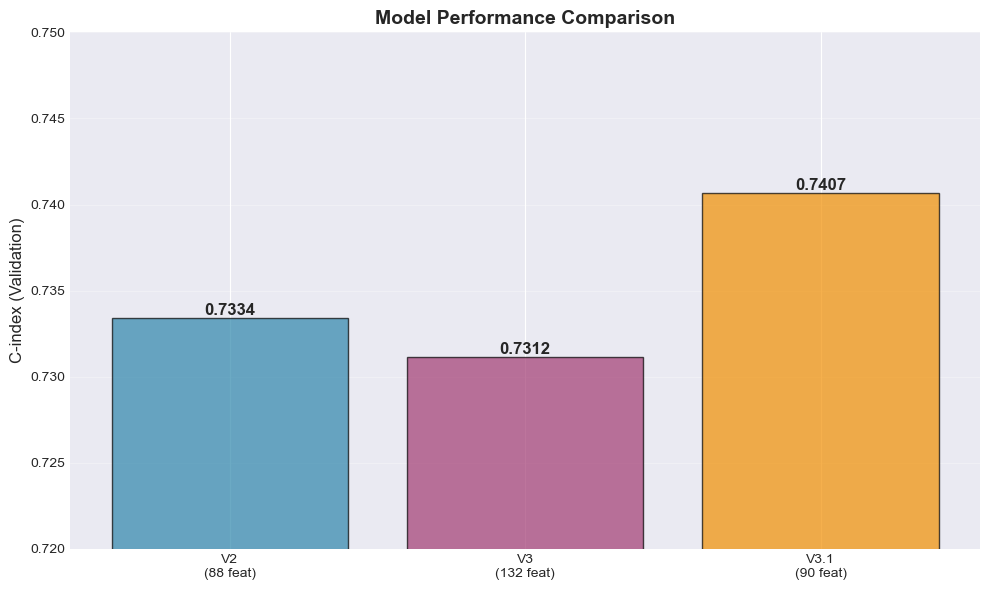

In [17]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

models = ['V2\n(88 feat)', 'V3\n(132 feat)', f'V3.1\n({int(best_n_features)} feat)']
scores = [0.7334, c_index_val_baseline, c_index_val_opt]
colors = ['#2E86AB', '#A23B72', '#F18F01']

bars = ax.bar(models, scores, color=colors, alpha=0.7, edgecolor='black')

# Add value labels
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('C-index (Validation)', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0.72, 0.75])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 10. Selected Features Analysis

In [18]:
# Analyze selected features breakdown
clinical_feature_names = X_clinical.columns.tolist()
molecular_feature_names = mol_features_train_aligned.columns.tolist()
cytogenetic_feature_names = cyto_features_train_aligned.columns.tolist()

selected_features_df = feature_importance_df.head(int(best_n_features)).copy()

def categorize_feature(feature):
    if feature in clinical_feature_names:
        return 'Clinical'
    elif feature in molecular_feature_names:
        return 'Molecular'
    else:
        return 'Cytogenetic'

selected_features_df['type'] = selected_features_df['feature'].apply(categorize_feature)

print("="*60)
print(f"SELECTED FEATURES BREAKDOWN (Top {int(best_n_features)})")
print("="*60)

breakdown = selected_features_df['type'].value_counts()
for ftype, count in breakdown.items():
    pct = count / len(selected_features_df) * 100
    print(f"{ftype}: {count} features ({pct:.1f}%)")

print(f"\nTop 20 selected features:")
print(selected_features_df.head(20)[['feature', 'type', 'importance']].to_string(index=False))

SELECTED FEATURES BREAKDOWN (Top 90)
Molecular: 43 features (47.8%)
Cytogenetic: 24 features (26.7%)
Clinical: 23 features (25.6%)

Top 20 selected features:
                    feature        type  importance
                   BM_BLAST    Clinical    0.013167
                         HB    Clinical    0.011784
                        PLT    Clinical    0.007542
                    vaf_sum   Molecular    0.007369
       mutation_count_total   Molecular    0.005332
effect_non_synonymous_codon   Molecular    0.002312
           gene_RUNX1_count   Molecular    0.002152
                        WBC    Clinical    0.002143
       cyto_total_anomalies Cytogenetic    0.002104
         gene_RUNX1_present   Molecular    0.001675
                        ANC    Clinical    0.001447
                cyto_normal Cytogenetic    0.001359
                  MONOCYTES    Clinical    0.001253
                   vaf_mean   Molecular    0.001204
            gene_TP53_count   Molecular    0.001158
          

## 11. Test Set Prediction

In [ ]:
print("="*60)
print("TEST SET PREPARATION")
print("="*60)

# Create features for test set
cyto_features_test = create_cytogenetic_features(clinical_test)
test_patient_ids = clinical_test['ID'].unique()
mol_features_test = create_molecular_features(molecular_test, test_patient_ids, top_n_genes=20)

# Clinical features
clinical_test_indexed = clinical_test.set_index('ID')
X_numeric_test = clinical_test_indexed[numeric_features].copy()
center_encoded_test = pd.get_dummies(clinical_test_indexed['CENTER'], prefix='CENTER', drop_first=True)
for col in center_encoded.columns:
    if col not in center_encoded_test.columns:
        center_encoded_test[col] = 0
center_encoded_test = center_encoded_test[center_encoded.columns]
X_clinical_test = pd.concat([X_numeric_test, center_encoded_test], axis=1)

# Combine
mol_features_test_aligned = mol_features_test.reindex(X_clinical_test.index, fill_value=0)
cyto_features_test_aligned = cyto_features_test.reindex(X_clinical_test.index, fill_value=0)
X_test_combined = pd.concat([X_clinical_test, mol_features_test_aligned, cyto_features_test_aligned], axis=1)

# Align columns
for col in X_combined.columns:
    if col not in X_test_combined.columns:
        X_test_combined[col] = 0
X_test_combined = X_test_combined[X_combined.columns]

# Impute
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_combined),
    index=X_test_combined.index,
    columns=X_test_combined.columns
)

# Select best features
X_test_best = X_test_imputed[best_features]

print(f"✓ Test set prepared: {X_test_best.shape}")

In [ ]:
# Retrain on full training data
print("\nRetraining optimized model on full training set...")

X_full_best = X_imputed[best_features]

rsf_final = RandomSurvivalForest(
    n_estimators=int(best_params['n_estimators']),
    min_samples_split=int(best_params['min_samples_split']),
    min_samples_leaf=int(best_params['min_samples_leaf']),
    max_features=best_params['max_features'],
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rsf_final.fit(X_full_best, y_surv)
print("\n✓ Final model trained on complete dataset")

In [ ]:
# Generate predictions
predictions_test = rsf_final.predict(X_test_best)

submission = pd.DataFrame({
    'ID': X_test_best.index,
    'PRED': predictions_test
})

submission_path = f"{DATA_PATH}\\submission_rsf_optimized.csv"
submission.to_csv(submission_path, index=False)

print("="*60)
print("SUBMISSION GENERATED")
print("="*60)
print(f"File: {submission_path}")
print(f"Predictions: {len(submission)}")
print(f"\nStatistics:")
print(submission['PRED'].describe())

## 12. Summary

In [ ]:
print("="*60)
print("VERSION 3.1 OPTIMIZATION SUMMARY")
print("="*60)

print("\n📊 RESULTS:")
print(f"  V2 baseline: 0.7334 (88 features)")
print(f"  V3 baseline: {c_index_val_baseline:.4f} (132 features) ⚠️")
print(f"  V3.1 optimized: {c_index_val_opt:.4f} ({int(best_n_features)} features) ✓")

print("\n🔧 OPTIMIZATIONS APPLIED:")
print(f"  1. Feature selection: 132 → {int(best_n_features)} features")
print(f"  2. Hyperparameter tuning:")
for param, value in best_params.items():
    print(f"     - {param}: {value}")

print("\n📈 IMPROVEMENT:")
print(f"  vs V2: {improvement_vs_v2:+.2f}%")
print(f"  vs V3: {improvement_vs_v3:+.2f}%")

print("\n✅ OUTPUT:")
print(f"  Submission file: submission_rsf_optimized.csv")
print(f"  Selected features: {int(best_n_features)}")
print(f"  Final C-index: {c_index_val_opt:.4f}")